ОТБОР ЧИСТЫХ ПАТЧЕЙ С RLE РАЗМЕТКОЙ (70/15/15)

📁 ПОИСК ИЗОБРАЖЕНИЙ:
  Найдено изображений: 34077

📊 АНАЛИЗ ИЗОБРАЖЕНИЙ:
  Проанализировано: 5000 изображений

🔍 КЛАСТЕРИЗАЦИЯ:
  Кластеров: 20

📦 ОТБОР 2000 ИЗОБРАЖЕНИЙ:
  Отобрано: 1766

📊 РАЗБИЕНИЕ 70/15/15:
  train: 1236 изображений
  val: 264 изображений
  test: 266 изображений

📁 КОПИРОВАНИЕ:
  ✅ Скопировано: train=1236, val=264, test=266

💾 СОХРАНЕНИЕ RLE РАЗМЕТКИ (пустые дефекты):
  ✅ train: 1236 записей (пустые) → data/256_yolo/balanced_clean_patches_rle/train/train_rle.csv
  ✅ val: 264 записей (пустые) → data/256_yolo/balanced_clean_patches_rle/val/val_rle.csv
  ✅ test: 266 записей (пустые) → data/256_yolo/balanced_clean_patches_rle/test/test_rle.csv
  📊 Всего RLE записей: 1766


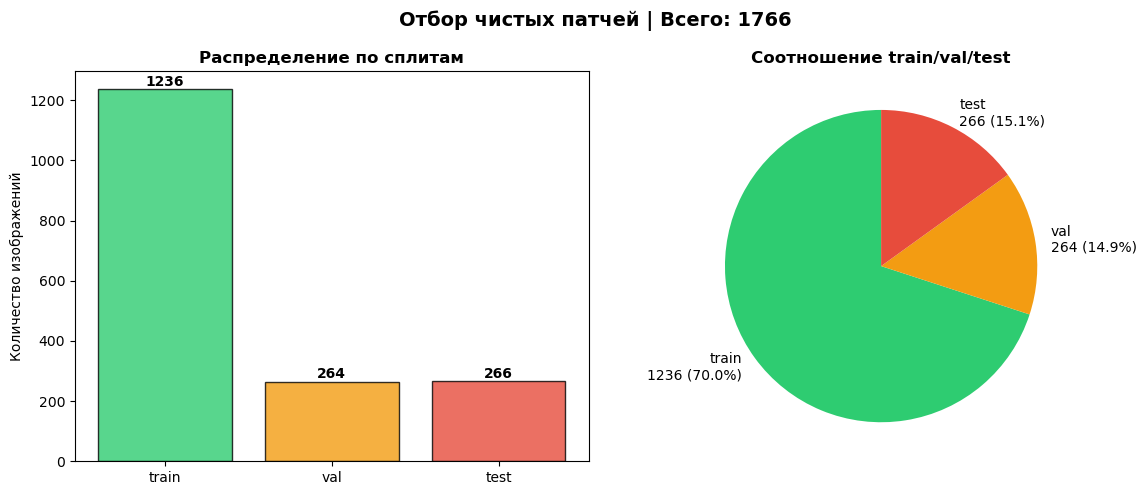


✅ ГОТОВО! ЧИСТЫЕ ПАТЧИ С RLE РАЗМЕТКОЙ

📁 ВЫХОДНАЯ ПАПКА: data/256_yolo/balanced_clean_patches_rle
   ├── train/
   │   ├── images/ (1236 файлов)
   │   ├── labels/ (1236 пустых файлов)
   │   └── train_rle.csv
   ├── val/
   │   ├── images/ (264 файлов)
   │   ├── labels/ (264 пустых файлов)
   │   └── val_rle.csv
   └── test/
       ├── images/ (266 файлов)
       ├── labels/ (266 пустых файлов)
       └── test_rle.csv

📊 СТАТИСТИКА:
   Всего отобрано: 1766 изображений
   Train: 1236 (70.0%)
   Val:   264 (14.9%)
   Test:  266 (15.1%)

💡 RLE файлы содержат пустые значения (чистые патчи)



In [1]:
#!/usr/bin/env python3
"""
select_balanced_clean_patches_rle.py - Отбор сбалансированных чистых патчей с RLE разметкой
Использует кластеризацию для равномерного покрытия + сохраняет пустую RLE разметку
"""

import numpy as np
import pandas as pd
from pathlib import Path
import shutil
import random
import cv2
from collections import defaultdict
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ============================================
# НАСТРОЙКИ
# ============================================

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

DATA_PATH = Path("data/256_yolo/clean_patches")
OUTPUT_PATH = Path("data/256_yolo/balanced_clean_patches_rle")
TARGET_COUNT = 2000

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

print("="*80)
print("ОТБОР ЧИСТЫХ ПАТЧЕЙ С RLE РАЗМЕТКОЙ (70/15/15)")
print("="*80)

# ============================================
# 1. ПОИСК ВСЕХ ИЗОБРАЖЕНИЙ
# ============================================

print(f"\n📁 ПОИСК ИЗОБРАЖЕНИЙ:")

all_images = []
for ext in ['*.png', '*.jpg', '*.jpeg']:
    all_images.extend(DATA_PATH.rglob(ext))

print(f"  Найдено изображений: {len(all_images)}")

if len(all_images) == 0:
    print("  ❌ Изображения не найдены!")
    exit(1)

if len(all_images) <= TARGET_COUNT:
    print(f"  ⚠️ Изображений меньше {TARGET_COUNT}, будут отобраны все")
    selected_images = all_images
    clusters = None
else:
    # ============================================
    # 2. АНАЛИЗ И КЛАСТЕРИЗАЦИЯ
    # ============================================
    
    print(f"\n📊 АНАЛИЗ ИЗОБРАЖЕНИЙ:")
    
    features = []
    valid_images = []
    sample_size = min(5000, len(all_images))
    sample_images = random.sample(all_images, sample_size)
    
    for img_path in sample_images:
        img = cv2.imread(str(img_path))
        if img is not None:
            # Извлекаем признаки: яркость, контраст, гистограмма
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            mean_val = np.mean(gray)
            std_val = np.std(gray)
            hist = cv2.calcHist([gray], [0], None, [32], [0, 256])
            hist = hist.flatten() / hist.sum()
            feat = np.concatenate([[mean_val, std_val], hist[:10]])
            features.append(feat)
            valid_images.append(img_path)
    
    features = np.array(features)
    print(f"  Проанализировано: {len(features)} изображений")
    
    print(f"\n🔍 КЛАСТЕРИЗАЦИЯ:")
    n_clusters = 20
    kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_SEED, n_init=10)
    clusters = kmeans.fit_predict(features)
    
    cluster_images = defaultdict(list)
    for img_path, cluster in zip(valid_images, clusters):
        cluster_images[cluster].append(img_path)
    
    print(f"  Кластеров: {n_clusters}")
    
    # ============================================
    # 3. РАВНОМЕРНЫЙ ОТБОР
    # ============================================
    
    print(f"\n📦 ОТБОР {TARGET_COUNT} ИЗОБРАЖЕНИЙ:")
    
    per_cluster = TARGET_COUNT // n_clusters
    remainder = TARGET_COUNT % n_clusters
    
    selected_images = []
    
    for cluster_id in range(n_clusters):
        available = cluster_images[cluster_id]
        to_select = per_cluster + (1 if cluster_id < remainder else 0)
        to_select = min(to_select, len(available))
        selected = random.sample(available, to_select)
        selected_images.extend(selected)
    
    print(f"  Отобрано: {len(selected_images)}")

# ============================================
# 4. РАЗБИЕНИЕ НА TRAIN/VAL/TEST
# ============================================

print(f"\n📊 РАЗБИЕНИЕ 70/15/15:")

random.shuffle(selected_images)

total = len(selected_images)
train_end = int(total * TRAIN_RATIO)
val_end = train_end + int(total * VAL_RATIO)

splits = {
    'train': selected_images[:train_end],
    'val': selected_images[train_end:val_end],
    'test': selected_images[val_end:]
}

for split_name, split_images in splits.items():
    print(f"  {split_name}: {len(split_images)} изображений")

# ============================================
# 5. СОЗДАНИЕ СТРУКТУРЫ И КОПИРОВАНИЕ
# ============================================

print(f"\n📁 КОПИРОВАНИЕ:")

if OUTPUT_PATH.exists():
    shutil.rmtree(OUTPUT_PATH)

for split_name in ['train', 'val', 'test']:
    (OUTPUT_PATH / split_name / "images").mkdir(parents=True)
    (OUTPUT_PATH / split_name / "labels").mkdir(parents=True)

copied = {'train': 0, 'val': 0, 'test': 0}

for split_name, split_images in splits.items():
    for img_path in split_images:
        # Копируем изображение
        dst_img = OUTPUT_PATH / split_name / "images" / img_path.name
        if dst_img.exists():
            dst_img = OUTPUT_PATH / split_name / "images" / f"{img_path.stem}_{copied[split_name]}{img_path.suffix}"
        shutil.copy2(img_path, dst_img)
        
        # Создаем пустой label файл (чистый патч = нет дефектов)
        label_name = dst_img.stem + ".txt"
        dst_lbl = OUTPUT_PATH / split_name / "labels" / label_name
        dst_lbl.touch()  # Пустой файл
        
        copied[split_name] += 1

print(f"  ✅ Скопировано: train={copied['train']}, val={copied['val']}, test={copied['test']}")

# ============================================
# 6. СОХРАНЕНИЕ RLE ДАННЫХ (пустые)
# ============================================

print(f"\n💾 СОХРАНЕНИЕ RLE РАЗМЕТКИ (пустые дефекты):")

def save_empty_rle_for_split(split_name, split_images, output_dir):
    """Создает CSV с пустыми RLE для чистых патчей"""
    rle_data = []
    
    for img_path in split_images:
        # Имя файла с расширением
        if not img_path.suffix:
            patch_name = img_path.name + '.png'
        else:
            patch_name = img_path.name
        
        rle_data.append({
            'ImageId': patch_name,
            'ClassId': '',
            'EncodedPixels': ''
        })
    
    df_rle = pd.DataFrame(rle_data)
    csv_path = output_dir / split_name / f"{split_name}_rle.csv"
    df_rle.to_csv(csv_path, index=False)
    print(f"  ✅ {split_name}: {len(df_rle)} записей (пустые) → {csv_path}")
    
    return len(df_rle)

total_rle = 0
for split_name, split_images in splits.items():
    count = save_empty_rle_for_split(split_name, split_images, OUTPUT_PATH)
    total_rle += count

print(f"  📊 Всего RLE записей: {total_rle}")

# ============================================
# 7. СОХРАНЕНИЕ МЕТАДАННЫХ
# ============================================

# Сохраняем информацию о выбранных файлах
metadata = []
for split_name, split_images in splits.items():
    for img_path in split_images:
        metadata.append({
            'split': split_name,
            'filename': img_path.name,
            'original_path': str(img_path)
        })

df_metadata = pd.DataFrame(metadata)
df_metadata.to_csv(OUTPUT_PATH / "clean_patches_metadata.csv", index=False)

# Сохраняем конфиг
config = {
    'path': str(OUTPUT_PATH.absolute()),
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'description': 'Balanced clean patches with empty RLE annotations',
    'target_count': TARGET_COUNT,
    'total_selected': total
}

import json
with open(OUTPUT_PATH / "dataset_config.json", 'w') as f:
    json.dump(config, f, indent=2)

# ============================================
# 8. ВИЗУАЛИЗАЦИЯ
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Распределение по сплитам
split_names = ['train', 'val', 'test']
split_counts = [len(splits[s]) for s in split_names]
colors = ['#2ecc71', '#f39c12', '#e74c3c']

axes[0].bar(split_names, split_counts, color=colors, alpha=0.8, edgecolor='black')
axes[0].set_title('Распределение по сплитам', fontweight='bold')
axes[0].set_ylabel('Количество изображений')

# Добавляем значения
for i, (name, count) in enumerate(zip(split_names, split_counts)):
    axes[0].text(i, count + max(split_counts)*0.01, str(count), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(split_counts, labels=[f'{n}\n{c} ({c/total*100:.1f}%)' for n, c in zip(split_names, split_counts)],
           colors=colors, autopct='', startangle=90)
axes[1].set_title('Соотношение train/val/test', fontweight='bold')

plt.suptitle(f'Отбор чистых патчей | Всего: {total}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'clean_patches_distribution.png', dpi=150)
plt.show()

# ============================================
# 9. ИТОГ
# ============================================

print("\n" + "="*80)
print("✅ ГОТОВО! ЧИСТЫЕ ПАТЧИ С RLE РАЗМЕТКОЙ")
print("="*80)
print(f"""
📁 ВЫХОДНАЯ ПАПКА: {OUTPUT_PATH}
   ├── train/
   │   ├── images/ ({copied['train']} файлов)
   │   ├── labels/ ({copied['train']} пустых файлов)
   │   └── train_rle.csv
   ├── val/
   │   ├── images/ ({copied['val']} файлов)
   │   ├── labels/ ({copied['val']} пустых файлов)
   │   └── val_rle.csv
   └── test/
       ├── images/ ({copied['test']} файлов)
       ├── labels/ ({copied['test']} пустых файлов)
       └── test_rle.csv

📊 СТАТИСТИКА:
   Всего отобрано: {total} изображений
   Train: {copied['train']} ({copied['train']/total*100:.1f}%)
   Val:   {copied['val']} ({copied['val']/total*100:.1f}%)
   Test:  {copied['test']} ({copied['test']/total*100:.1f}%)

💡 RLE файлы содержат пустые значения (чистые патчи)
""")